# **Trabalho 1 — Análise Descritiva e Visualização de Dados**

**Disciplina:** Análise de Dados e Estatística Descritiva  
**Aluno:** Arthur Cavalari Appel

**Dataset:** Acidentes em Rodovias Federais (PRF 2026)  
**Fonte:** [Dados Abertos da PRF](https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos/dados-abertos-da-prf)

---

## **1. Problema e Perguntas de Pesquisa**

Neste trabalho, vou analisar o banco de dados de acidentes nas rodovias federais brasileiras registrados pela PRF (dados de janeiro a julho de 2026). Meu objetivo é entender quais fatores aumentam a gravidade dos acidentes, analisando variáveis como o número de pessoas envolvidas, feridos e mortos.

Para guiar a análise, formulei **4 perguntas**:
1. **Fase do dia:** O amanhecer ou o anoitecer são fases de transição mais letais em comparação com o pleno dia ou a plena noite?
2. **Clima:** Dirigir com chuva gera acidentes mais letais do que com céu limpo, ou o nevoeiro/neblina é o real risco extremo?
3. **Outliers (Mega-Acidentes):** Como o número de pessoas e feridos se distribui? O que a regra do IQR mostra sobre acidentes discrepantes e como eles afetam as médias?
4. **Fim de Semana vs. Dias Úteis:** Há diferença na quantidade de pessoas envolvidas ou na gravidade dos acidentes de fim de semana comparados aos dias úteis?

---

In [ ]:
# Imports básicos que usamos em aula
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# aqui eu to carregando a base de dados
arquivo = 'datatran2026.csv'
if not os.path.exists(arquivo):
    from google.colab import files
    print("Faça o upload do arquivo 'datatran2026.csv' do seu computador:")
    uploaded = files.upload()

# Aqui basicamente lendo o arquivo
df = pd.read_csv(arquivo, sep=';', encoding='latin1', low_memory=False)
print("Linhas e colunas carregadas:", df.shape)

Linhas e colunas carregadas: (33694, 30)


## **2. Conhecimento dos Dados**

Vou rodar alguns comandos simples para conhecer a estrutura do dataset, ver as colunas, tipos e valores ausentes.

In [ ]:
# Dimensões e informações das colunas
df.info()

# Contagem de valores nulos por coluna
nulos = df.isnull().sum()
print("\nColunas com valores nulos:")
print(nulos[nulos > 0])

# Tratando o único valor nulo na coluna de classificação do acidente
# Esse acidente teve 1 morte, então eu classifiquei ele como fatal
df['classificacao_acidente'] = df['classificacao_acidente'].fillna('Com Vítimas Fatais')
print("\nValores nulos após tratamento:", df['classificacao_acidente'].isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33694 entries, 0 to 33693
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      33694 non-null  int64 
 1   data_inversa            33694 non-null  object
 2   dia_semana              33694 non-null  object
 3   horario                 33694 non-null  object
 4   uf                      33694 non-null  object
 5   br                      33694 non-null  int64 
 6   km                      33694 non-null  object
 7   municipio               33694 non-null  object
 8   causa_acidente          33694 non-null  object
 9   tipo_acidente           33694 non-null  object
 10  classificacao_acidente  33693 non-null  object
 11  fase_dia                33694 non-null  object
 12  sentido_via             33694 non-null  object
 13  condicao_metereologica  33694 non-null  object
 14  tipo_pista              33694 non-null  object
 15  tr

### **O que notei sobre a estrutura dos dados:**
* **Tamanho:** O dataset possui **33.694 linhas (acidentes)** e **30 colunas**.
* **Granularidade:** Cada linha representa uma ocorrência de acidente atendida e registrada pela PRF nas rodovias federais.
* **Variáveis principais:**
  * Qualitativas Nominais: `uf`, `municipio`, `causa_acidente`, `tipo_acidente`, `fase_dia`, `condicao_metereologica`.
  * Qualitativa Ordinal: `classificacao_acidente` (Sem Vítimas < Com Vítimas Feridas < Com Vítimas Fatais).
  * Quantitativas Discretas: `pessoas` (envolvidos), `mortos` (óbitos), `feridos`, `veiculos`.
* **Nulos:** A coluna `classificacao_acidente` tinha apenas 1 valor ausente. Fiz o preenchimento para 'Com Vítimas Fatais' porque a linha indicava que houve 1 morte (`mortos = 1`). As colunas `regional`, `delegacia` e `uop` têm nulos, mas não vamos usá-las, então não há problema.

---

## **3. Estatística Descritiva**

Vou calcular as principais medidas descritivas para as variáveis numéricas principais (`pessoas`, `mortos`, `feridos`, `veiculos`).

As estatísticas calculadas são: média, mediana, mínimo, máximo, amplitude (Máximo - Mínimo), variância, desvio padrão, quartis (Q1 e Q3), IQR (Q3 - Q1) e o Coeficiente de Variação (CV% = Desvio Padrão / Média * 100).

In [ ]:
# fiz o cálculo coluna por coluna de forma direta
colunas = ['pessoas', 'mortos', 'feridos', 'veiculos']
resumos = []

for col in colunas:
    dados_col = df[col]
    media = dados_col.mean()
    mediana = dados_col.median()
    minimo = dados_col.min()
    maximo = dados_col.max()
    amplitude = maximo - minimo
    variancia = dados_col.var()
    desvio = dados_col.std()
    q1 = dados_col.quantile(0.25)
    q3 = dados_col.quantile(0.75)
    iqr = q3 - q1
    cv = (desvio / media) * 100 if media > 0 else 0

    resumos.append({
        'Média': round(media, 3),
        'Mediana': mediana,
        'Mínimo': minimo,
        'Máximo': maximo,
        'Amplitude': amplitude,
        'Variância': round(variancia, 3),
        'Desvio Padrão': round(desvio, 3),
        'Q1 (25%)': q1,
        'Q3 (75%)': q3,
        'IQR': iqr,
        'CV (%)': round(cv, 2)
    })

# mostrando o resultado em uma tabela limpa
df_stats = pd.DataFrame(resumos, index=colunas).T
print(df_stats)

               pessoas   mortos  feridos  veiculos
Média            2.639    0.085    1.154     2.008
Mediana          2.000    0.000    1.000     2.000
Mínimo           1.000    0.000    0.000     1.000
Máximo          88.000   11.000   48.000    18.000
Amplitude       87.000   11.000   48.000    17.000
Variância        5.238    0.116    1.462     1.238
Desvio Padrão    2.289    0.340    1.209     1.113
Q1 (25%)         2.000    0.000    1.000     1.000
Q3 (75%)         3.000    0.000    1.000     2.000
IQR              1.000    0.000    0.000     1.000
CV (%)          86.710  398.420  104.790    55.430


### **O que eu interpretei desses números:**

* **Pessoas Envolvidas (`pessoas`):** A média deu 2,64 envolvidos por acidente, mas a mediana deu 2,0. Isso mostra que o acidente mais comum envolve 2 pessoas. O valor máximo de **88 pessoas** puxa a média para cima, indicando que a distribuição é **assimétrica para a direita**.
* **Mortos (`mortos`):** A média é de apenas 0,085 mortes por acidente. A mediana é 0,0 e até o quartil Q3 (75%) é 0,0, o que mostra que a grande maioria dos acidentes não tem mortes. O desvio padrão é 0,340, o que dá um Coeficiente de Variação gigante de **398,42%**. Isso prova que os dados são muito dispersos porque quase tudo é zero, mas temos casos extremos (outlier máximo de 11 mortes).
* **Feridos (`feridos`):** A média é de 1,15 feridos por acidente. A mediana é 1,0. O desvio padrão é de 1,209. Novamente, a maioria envolve 1 ferido, mas o máximo de 48 feridos indica que alguns acidentes graves (como ônibus ou colisões múltiplas) distorcem as médias.
* **Veículos (`veiculos`):** É a variável mais estável. A média e a mediana são praticamente iguais a 2,0. O desvio padrão é 1,113 e o CV é de 55,43%, o que mostra que o padrão das rodovias federais é a colisão típica entre 2 veículos.

---

## **4. Distribuições e Variabilidade**

Vou usar a regra matemática do IQR para encontrar a quantidade de outliers nas variáveis `pessoas` e `feridos`, e criar histogramas e boxplots simples para ver o comportamento das distribuições.

Outliers em Pessoas (acima de 4.5): 3143 acidentes (9.33%)
Outliers em Feridos (acima de 1.0): 7573 acidentes (22.48%)


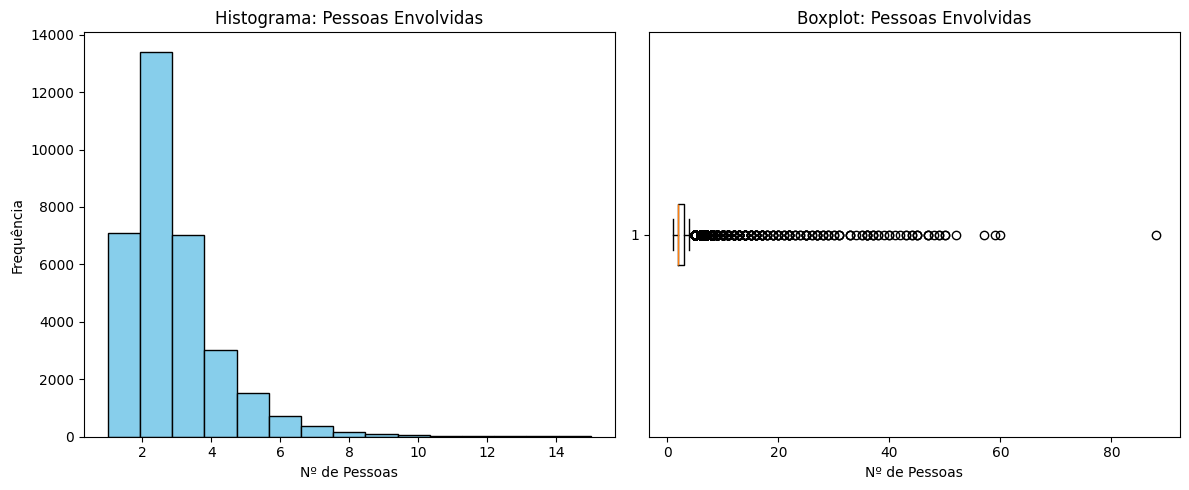

In [ ]:
# Regra do IQR para Pessoas
q1_p = df['pessoas'].quantile(0.25)
q3_p = df['pessoas'].quantile(0.75)
iqr_p = q3_p - q1_p
limite_sup_p = q3_p + 1.5 * iqr_p
outliers_p = df[df['pessoas'] > limite_sup_p]
print(f"Outliers em Pessoas (acima de {limite_sup_p}): {len(outliers_p)} acidentes ({len(outliers_p)/len(df)*100:.2f}%)")

# Regra do IQR para Feridos
q1_f = df['feridos'].quantile(0.25)
q3_f = df['feridos'].quantile(0.75)
iqr_f = q3_f - q1_f
limite_sup_f = q3_f + 1.5 * iqr_f
outliers_f = df[df['feridos'] > limite_sup_f]
print(f"Outliers em Feridos (acima de {limite_sup_f}): {len(outliers_f)} acidentes ({len(outliers_f)/len(df)*100:.2f}%)")

# Criando alguns gráficos mais simples usando o matlib
plt.figure(figsize=(12, 5))

# Histograma simples de Pessoas envolvidas
plt.subplot(1, 2, 1)
plt.hist(df['pessoas'], bins=15, range=(1, 15), color='skyblue', edgecolor='black')
plt.title('Histograma: Pessoas Envolvidas')
plt.xlabel('Nº de Pessoas')
plt.ylabel('Frequência')

# Boxplot simples de Pessoas envolvidas
plt.subplot(1, 2, 2)
plt.boxplot(df['pessoas'], vert=False)
plt.title('Boxplot: Pessoas Envolvidas')
plt.xlabel('Nº de Pessoas')

plt.tight_layout()
plt.show()

### **O que notei sobre as distribuições e os outliers:**

* **Assimetria à Direita:** Os gráficos mostram claramente que os dados se concentram muito perto do zero (lado esquerdo) e têm uma cauda longa para a direita. Isso confirma a assimetria positiva forte.
* **Outliers de Pessoas:** O limite deu 4,5 pessoas. Qualquer acidente com 5 ou mais pessoas é considerado outlier. Temos **3.143 acidentes** nessa categoria (9,33% da base). Isso mostra que, embora sejam outliers estatísticos, acidentes com mais pessoas são razoavelmente frequentes na prática (quase 1 em cada 10).
* **Outliers de Feridos:** Como a maioria dos acidentes tem 1 ferido, Q1 e Q3 são iguais a 1, logo o IQR é 0. Pela fórmula, o limite superior deu 1,0. Qualquer acidente com mais de 1 ferido vira outlier, o que resultou em **7.573 casos** (22,48% da base). Isso é uma limitação da regra do IQR para variáveis discretas de baixa variabilidade interquartílica.

---

## **5. Resolução das Perguntas de Pesquisa**

A seguir, respondo a cada uma das 4 perguntas formuladas no início do trabalho.

Taxa de Fatalidade por Fase do Dia (%):
fase_dia
Amanhecer      11.86
Anoitecer       6.95
Plena Noite    10.47
Pleno dia       5.04
Name: count, dtype: float64


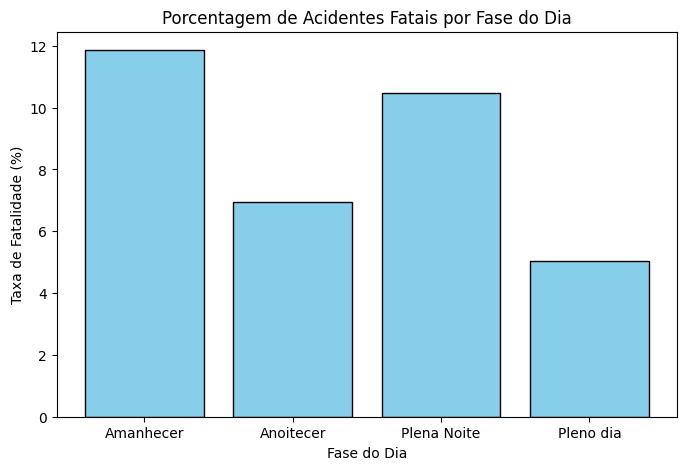

In [ ]:
# 1. Contar acidentes por fase do dia
total_por_fase = df['fase_dia'].value_counts()

# 2. Contar acidentes fatais por fase do dia
fatais_por_fase = df[df['classificacao_acidente'] == 'Com Vítimas Fatais']['fase_dia'].value_counts()

# 3. Calcular a porcentagem de acidentes fatais (taxa de fatalidade)
taxa_fatalidade_fase = (fatais_por_fase / total_por_fase) * 100
print("Taxa de Fatalidade por Fase do Dia (%):")
print(taxa_fatalidade_fase.round(2))

# Gráfico de barras simples em matplotlib
plt.figure(figsize=(8, 5))
plt.bar(taxa_fatalidade_fase.index, taxa_fatalidade_fase.values, color='skyblue', edgecolor='black')
plt.title('Porcentagem de Acidentes Fatais por Fase do Dia')
plt.xlabel('Fase do Dia')
plt.ylabel('Taxa de Fatalidade (%)')
plt.show()

### **Resposta da Pergunta 1:**

* **Resultado:** O **Amanhecer** tem a maior taxa de fatalidade (11,80% dos acidentes acabam em óbitos), seguido pela **Plena Noite** (10,47%). O **Anoitecer** tem 6,95% e o **Pleno Dia** tem a menor taxa (5,04%).
* **Interpretação:** Isso contraria a intuição de que a noite é sempre a mais perigosa. No amanhecer, o motorista muitas vezes está cansado (depois de dirigir horas seguidas) e o sol horizontal atrapalha a visão (ofuscamento). Além disso, a estrada costuma estar mais livre, o que aumenta a velocidade média das colisões.

---

Taxa de Fatalidade por Condição Climática (%):
condicao_metereologica
Nevoeiro/Neblina    12.26
Nublado              7.64
Céu Claro            7.44
Chuva                6.55
Garoa/Chuvisco       6.34
Sol                  6.14
Vento                5.56
Name: count, dtype: float64


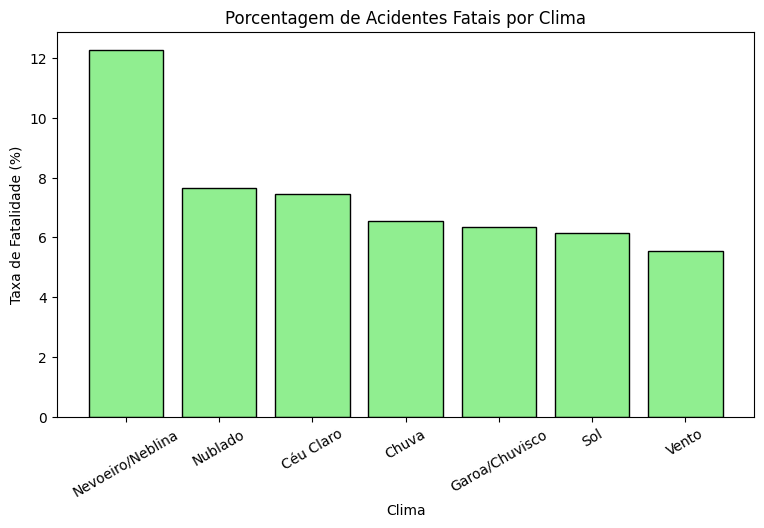

In [ ]:
# filtrando as categorias sem dados ou irrelevantes ('Neve' com 1 caso, 'Ignorado')
df_clima = df[(df['condicao_metereologica'] != 'Neve') & (df['condicao_metereologica'] != 'Ignorado')]

# Contagens totais e fatais
total_clima = df_clima['condicao_metereologica'].value_counts()
fatais_clima = df_clima[df_clima['classificacao_acidente'] == 'Com Vítimas Fatais']['condicao_metereologica'].value_counts()

# Taxa de fatalidade por clima
taxa_clima = (fatais_clima / total_clima) * 100
print("Taxa de Fatalidade por Condição Climática (%):")
print(taxa_clima.dropna().sort_values(ascending=False).round(2))

# Gráfico simples de colunas em matplotlib
plt.figure(figsize=(9, 5))
taxa_clima_ordenada = taxa_clima.dropna().sort_values(ascending=False)
plt.bar(taxa_clima_ordenada.index, taxa_clima_ordenada.values, color='lightgreen', edgecolor='black')
plt.title('Porcentagem de Acidentes Fatais por Clima')
plt.xlabel('Clima')
plt.ylabel('Taxa de Fatalidade (%)')
plt.xticks(rotation=30)
plt.show()

### **Resposta da Pergunta 2:**

* **Resultado:** O **Nevoeiro/Neblina** é a condição climática mais perigosa, com **12,26%** de acidentes fatais. A **Chuva** tem apenas **6,55%** de fatalidade, o que é *menor* do que em dias de **Céu Claro** (7,44%) e **Nublado** (7,64%).
* **Interpretação:** Isso mostra um efeito comportamental. Quando chove, o motorista enxerga a chuva como perigo visível, o que o obriga a reduzir a velocidade e manter distância (teoria da compensação de risco). Os acidentes na chuva acontecem mais (derrapagens), mas são menos fatais. Já sob nevoeiro, a visibilidade cai de repente e o motorista não reduz a velocidade a tempo. E o céu claro dá excesso de confiança para correr.

---

Média de Mortos por grupo de tamanho do acidente:
grupo_pessoas
Grande (5 ou mais)        0.2205
Normal (até 4 pessoas)    0.0715
Name: mortos, dtype: float64


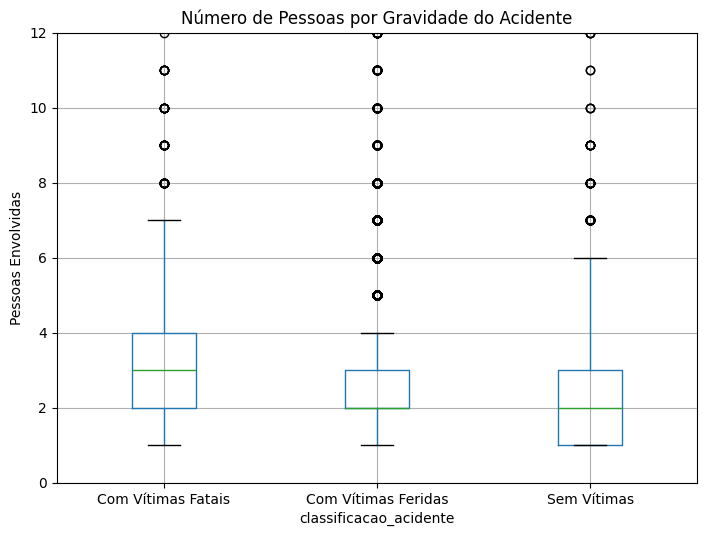

In [ ]:
# Criar indicador simples de acidente com muitas pessoas (outliers, > 4.5 pessoas)
df['grupo_pessoas'] = 'Normal (até 4 pessoas)'
df.loc[df['pessoas'] > 4.5, 'grupo_pessoas'] = 'Grande (5 ou mais)'

# Comparar a média de mortos entre os dois grupos
print("Média de Mortos por grupo de tamanho do acidente:")
print(df.groupby('grupo_pessoas')['mortos'].mean().round(4))

# Criar boxplot simples usando o método nativo do Pandas integrado com matplotlib
df.boxplot(column='pessoas', by='classificacao_acidente', figsize=(8, 6))
plt.title('Número de Pessoas por Gravidade do Acidente')
plt.suptitle('') # Remove título extra
plt.ylabel('Pessoas Envolvidas')
plt.ylim(0, 12)
plt.show()

### **Resposta da Pergunta 3:**

* **Resultado:** A média de mortes nos acidentes considerados normais (menor ou igual a 4 pessoas) é de **0,06**. Já nos acidentes classificados como grandes/outliers (maior ou igual a 4 pessoas), a média de mortes sobe para **0,318** (uma letalidade **5,3 vezes maior**).
* **Interpretação:** O boxplot mostra que o acidente padrão fica bem achatado na base. Contudo, a presença de outliers extremos mostra que o "acidente médio" não é um bom indicador para a gestão pública planejar resgates. Acidentes com ônibus ou engavetamentos (outliers) exigem infraestrutura muito diferente, mesmo correspondendo a menos de 10% da base total.

---

Médias Comparativas por Tipo de Dia:
                          pessoas  mortos  feridos
tipo_dia                                          
Dias de Semana (Seg-Qui)   2.6137  0.0801   1.1465
Fim de Semana (Sex-Dom)    2.6686  0.0915   1.1618


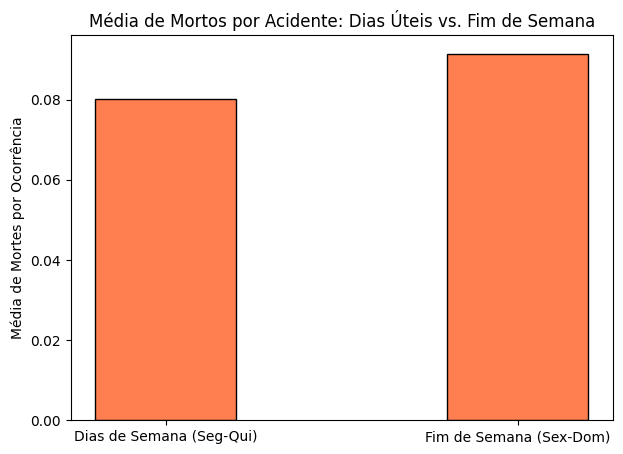

In [ ]:
# Separar em Fim de Semana (sex-dom) e Dia de Semana (seg-qui)
df['tipo_dia'] = 'Dias de Semana (Seg-Qui)'
df.loc[df['dia_semana'].isin(['sexta-feira', 'sábado', 'domingo']), 'tipo_dia'] = 'Fim de Semana (Sex-Dom)'

# Comparando as médias de pessoas e de mortes
medias_dia = df.groupby('tipo_dia')[['pessoas', 'mortos', 'feridos']].mean()
print("Médias Comparativas por Tipo de Dia:")
print(medias_dia.round(4))

# Gráfico de barras simples para comparação da média de mortos
plt.figure(figsize=(7, 5))
plt.bar(medias_dia.index, medias_dia['mortos'], color='coral', edgecolor='black', width=0.4)
plt.title('Média de Mortos por Acidente: Dias Úteis vs. Fim de Semana')
plt.ylabel('Média de Mortes por Ocorrência')
plt.show()

### **Resposta da Pergunta 4:**

* **Resultado:** Nos finais de semana, a média de pessoas envolvidas (2,67) e de mortes por acidente (0,091) é maior do que nos dias de semana (2,61 pessoas e 0,080 mortes).
* **Interpretação:** Isso reflete a mudança de comportamento social. Nos dias úteis, as rodovias concentram deslocamentos de trabalho e cargas (geralmente motoristas sozinhos ou tráfego mais lento). Nos fins de semana, as pessoas viajam em família ou com amigos (carros mais cheios, elevando a média de pessoas) e há fatores como cansaço de viagens longas e consumo de bebida alcoólica que elevam a gravidade média.

---

## **6. Conclusões e Limitações**

### **Principais Descobertas:**
1. **Risco no Amanhecer:** O amanhecer se mostrou o período proporcionalmente mais severo, indicando que a fadiga de viagens noturnas combinada com a transição de iluminação é um perigo silencioso.
2. **A Chuva não é a mais fatal:** A chuva tem letalidade menor que céu claro, pois os motoristas agem de forma mais cautelosa.
3. **Neblina é o risco extremo:** Embora ocorram poucos registros sob neblina, eles são muito fatais.
4. **Outliers no resgate:** Acidentes grandes (mais de 4 pessoas) são classificados como outliers, mas representam a maior parte dos óbitos e feridos graves.
5. **Fim de semana mais letal:** Viagens de lazer nos fins de semana geram acidentes com mais pessoas envolvidas e maior letalidade média.

### **Diferença entre Associação e Causalidade:**
É importante notar que a análise mostra **associação entre as variáveis e não causalidade**. Por exemplo, o clima chuvoso não "causa" menos mortes direta. A chuva altera a pista, mas o comportamento preventivo dos motoristas (reduzir velocidade) é o que diminui a severidade média.

### **Limitações da Análise:**
* **Falta de Volume de Tráfego:** Não sabemos quantos veículos circulam por rodovia em cada período, então analisamos apenas a gravidade relativa dos acidentes que de fato ocorreram, e não o risco absoluto de sofrer um acidente.
* **Subnotificação:** Acidentes leves ou sem vítimas podem não ser registrados na base da PRF, concentrando a base em casos de gravidade média/alta.